# Cycle 1 — Modelling


This notebook trains and evaluates machine learning models for predicting Premier League match outcomes (Home Win / Draw / Away Win).

I train 5 models in increasing complexity:

1. Dummy classifier(baseline)
2. Logistic Regression
3. Random Forest 
4. XGBoost 
5. LightGBM


In [18]:
import sys, os  # sys for path manipulation, os for directory checks

_here = os.getcwd()                                       
while not os.path.isdir(os.path.join(_here, 'data')):     
    _p = os.path.dirname(_here)                           
    if _p == _here: raise RuntimeError('project root not found') 
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)                              

from config import Paths, ensure_dirs  
ensure_dirs()  

import pandas as pd                       
import numpy as np                        
import warnings                           
import matplotlib.pyplot as plt           
warnings.filterwarnings('ignore')         

from sklearn.model_selection import train_test_split    # split data into train and test sets
from sklearn.preprocessing import StandardScaler         # z-score scaler for Logistic Regression
from sklearn.dummy import DummyClassifier                # always-predict-majority baseline
from sklearn.linear_model import LogisticRegression      # linear classifier
from sklearn.ensemble import RandomForestClassifier      # ensemble of decision trees
from sklearn.metrics import accuracy_score, classification_report  # evaluation metrics
from xgboost import XGBClassifier                        # gradient boosting (XGBoost)
from sklearn.svm import SVC                              # support vector classifier (imported for completeness)
from lightgbm import LGBMClassifier                      # gradient boosting (LightGBM — leaf-wise growth)

print('All libraries imported successfully')


All libraries imported successfully


## Load and Prepare Data

To prepare the processed dataset, I seperate features (X) from target (y), amd split into traint/test sets. 
The 80/20 train/test split is standard. `random_state=42` ensures reproducibility, running this again gives the same split.

In [19]:
df1 = pd.read_csv(str(Paths.PL_MATCHES_PROCESSED))  # load the preprocessed dataset

X1 = df1.drop(columns=['FTR', 'Season'])  # FTR is the target; Season is metadata, not a predictive feature
y1 = df1['FTR']                       

X1_train, X1_test, y1_train, y1_test = train_test_split(  # random 80/20 split
    X1, y1, test_size=0.2, random_state=42               # random_state=42 ensures reproducible splits
)

scaler1 = StandardScaler()                    # z-score scaler: mean=0, std=1 per feature
X1_train_s = scaler1.fit_transform(X1_train)  # fit on training data only — prevents leakage
X1_test_s  = scaler1.transform(X1_test)       # apply same scaling to test (no refit)

print('Total rows:', len(df1))
print('Features:', X1.shape[1])
print('Training rows:', len(X1_train))
print('Test rows:', len(X1_test))


Total rows: 6840
Features: 33
Training rows: 5472
Test rows: 1368


## Model 1: Dummy Classifier

- Always predicts the most frequent class (Home Win). No learning involved.
- Establishes the absolute minimum baseline. If a real model cannot beat this, it has learned nothing useful.

In [20]:
dummy1 = DummyClassifier(strategy='most_frequent', random_state=42)  # always predict the majority class (Home Win)
dummy1.fit(X1_train, y1_train)                                         # 'fit' just counts class frequencies
y_pred_dummy1 = dummy1.predict(X1_test)                                # predicts Home Win (2) for every row

print('DUMMY CLASSIFIER')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_dummy1):.4f} ({accuracy_score(y1_test, y_pred_dummy1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_dummy1, target_names=['Away Win', 'Draw', 'Home Win']))  # per-class breakdown


DUMMY CLASSIFIER
Accuracy: 0.4635 (46.35%)

              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00       394
        Draw       0.00      0.00      0.00       340
    Home Win       0.46      1.00      0.63       634

    accuracy                           0.46      1368
   macro avg       0.15      0.33      0.21      1368
weighted avg       0.21      0.46      0.29      1368



- Accuracy: **46.35%** 
- This reflects the class imbalance: Home Win (46.4% of training data) is the safe default guess
- A baseline of 46.35% means we need to significantly exceed this to claim the model is learning anything
- Draw prediction is the hardest class — all models struggle here

## Model 2: Logistic Regression

**`class_weight='balanced'`:** Adjusts for class imbalance automatically — gives more weight to minority classes (Draw, Away Win) during training.

In [27]:
lr1 = LogisticRegression(
    max_iter=1000,           # increase from default 100 to ensure convergence on 33 features
    class_weight='balanced', # up-weight minority classes (Draw, Away Win) to counter imbalance
    random_state=42          # reproducibility for solver initialization
)
lr1.fit(X1_train_s, y1_train)         # train on z-scored features — LR is scale-sensitive
y_pred_lr1 = lr1.predict(X1_test_s)  # predict on scaled test set

print('LOGISTIC REGRESSION')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_lr1):.4f} ({accuracy_score(y1_test, y_pred_lr1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_lr1, target_names=['Away Win', 'Draw', 'Home Win']))


LOGISTIC REGRESSION
Accuracy: 0.4985 (49.85%)

              precision    recall  f1-score   support

    Away Win       0.46      0.59      0.52       394
        Draw       0.30      0.25      0.27       340
    Home Win       0.64      0.57      0.60       634

    accuracy                           0.50      1368
   macro avg       0.46      0.47      0.46      1368
weighted avg       0.50      0.50      0.50      1368



- Accuracy: **49.85%** — beats the dummy by **3.50 percentage points**
The model is actually learning
- Home Win: best precision (0.64) — model is fairly confident when it predicts a home win
- Draw: worst performance (f1 = 0.27) — draws are genuinely difficult to predict
- Away Win: good recall (0.59) — catches roughly 60% of actual away wins

## Model 3: Random Forest

In [22]:
rf1 = RandomForestClassifier(
    n_estimators=100,        # build 100 trees — stable ensemble without tuning
    class_weight='balanced', # compensate for Home Win majority class
    random_state=42          # reproducibility for tree construction
)
rf1.fit(X1_train, y1_train)          # tree models don't need scaled features
y_pred_rf1 = rf1.predict(X1_test)    # predict on raw (unscaled) test features

print('RANDOM FOREST')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_rf1):.4f} ({accuracy_score(y1_test, y_pred_rf1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_rf1, target_names=['Away Win', 'Draw', 'Home Win']))


RANDOM FOREST
Accuracy: 0.5139 (51.39%)

              precision    recall  f1-score   support

    Away Win       0.50      0.42      0.45       394
        Draw       0.28      0.10      0.14       340
    Home Win       0.55      0.80      0.65       634

    accuracy                           0.51      1368
   macro avg       0.44      0.44      0.42      1368
weighted avg       0.47      0.51      0.47      1368



- Accuracy: **51.39%** — beats Logistic Regression by **1.54 percentage points**
- Home Win recall is high (0.80) — very good at identifying home wins
- Draw recall drops to **0.10** — the model barely predicts draws at all
- The progression Dummy → LogReg → RF (46% → 50% → 51%) shows consistent improvement
- Draw prediction remains the weakest point — a pattern across all models

## Model 4: XGBoost

In [23]:
xgb1 = XGBClassifier(
    n_estimators=100,        # 100 boosting rounds — default starting point before tuning
    random_state=42,         # reproducibility for tree sampling
    eval_metric='mlogloss',  # multi-class log loss — correct metric for 3-class problem
    verbosity=0              # suppress XGBoost training output
)
xgb1.fit(X1_train, y1_train)          # train on raw features (XGBoost handles scale internally)
y_pred_xgb1 = xgb1.predict(X1_test)  # predict class labels for test set

print('XGBOOST')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_xgb1):.4f} ({accuracy_score(y1_test, y_pred_xgb1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_xgb1, target_names=['Away Win', 'Draw', 'Home Win']))


XGBOOST
Accuracy: 0.5095 (50.95%)

              precision    recall  f1-score   support

    Away Win       0.47      0.43      0.45       394
        Draw       0.34      0.20      0.25       340
    Home Win       0.57      0.73      0.64       634

    accuracy                           0.51      1368
   macro avg       0.46      0.45      0.45      1368
weighted avg       0.48      0.51      0.49      1368



- Accuracy: **50.95%** — slightly below Random Forest (51.39%) without tuning
- Better draw prediction than Random Forest (recall **0.20 vs 0.10**)
- XGBoost is more balanced across all three classes
- With hyperparameter tuning, XGBoost typically surpasses Random Forest

## Model 5: LightGBM

In [24]:
lgb1 = LGBMClassifier(
    n_estimators=100,  # 100 boosting rounds — same as XGBoost for fair comparison
    random_state=42,   # reproducibility
    verbose=-1         # suppress LightGBM training output
)
lgb1.fit(X1_train, y1_train)          # train on raw features
y_pred_lgb1 = lgb1.predict(X1_test)  # predict class labels

print('LIGHTGBM')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_lgb1):.4f} ({accuracy_score(y1_test, y_pred_lgb1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_lgb1, target_names=['Away Win', 'Draw', 'Home Win']))


LIGHTGBM
Accuracy: 0.5402 (54.02%)

              precision    recall  f1-score   support

    Away Win       0.54      0.44      0.49       394
        Draw       0.34      0.18      0.23       340
    Home Win       0.58      0.79      0.67       634

    accuracy                           0.54      1368
   macro avg       0.49      0.47      0.46      1368
weighted avg       0.51      0.54      0.51      1368



## Model Comparison - Summary of Results 

In [25]:
results_d1 = pd.DataFrame({                    # build summary dataframe with all model results
    'Model': ['Dummy Classifier', 'Logistic Regression', 'Random Forest', 'XGBoost','LightGBM'],
    'Accuracy': [
        accuracy_score(y1_test, y_pred_dummy1),  # dummy baseline (floor)
        accuracy_score(y1_test, y_pred_lr1),     # logistic regression
        accuracy_score(y1_test, y_pred_rf1),     # random forest
        accuracy_score(y1_test, y_pred_xgb1),    # xgboost
        accuracy_score(y1_test, y_pred_lgb1)     # lightgbm
    ]
})
results_d1['Accuracy %'] = (results_d1['Accuracy'] * 100).round(2)                            # convert to percentage
results_d1['vs Dummy'] = ((results_d1['Accuracy'] - results_d1['Accuracy'].iloc[0]) * 100).round(2)  # gain over baseline
print(results_d1.to_string(index=False))


              Model  Accuracy  Accuracy %  vs Dummy
   Dummy Classifier  0.463450       46.35      0.00
Logistic Regression  0.498538       49.85      3.51
      Random Forest  0.513889       51.39      5.04
            XGBoost  0.509503       50.95      4.61
           LightGBM  0.540205       54.02      7.68


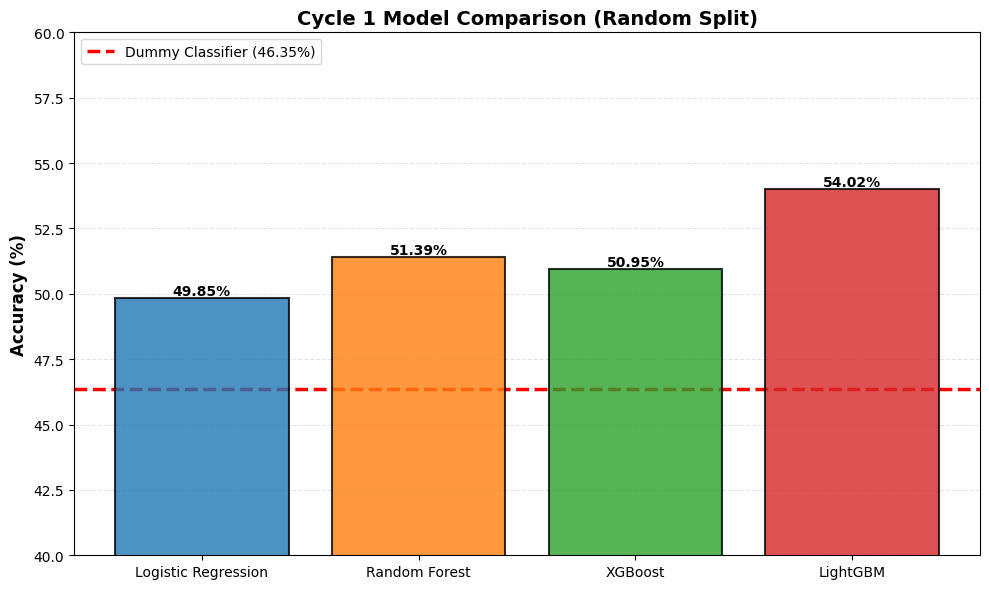

Chart saved as cycle1_model_comparison.png


In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

models = results_d1['Model'].values          # model names for labelling
accuracies = results_d1['Accuracy %'].values  # accuracy values for bars

dummy_acc = accuracies[0]                    # dummy accuracy for the reference line
ax.axhline(y=dummy_acc, color='red', linestyle='--', linewidth=2.5,
           label=f'Dummy Classifier ({dummy_acc:.2f}%)', zorder=1)  # red dashed line = floor to beat

model_names = models[1:]                     # exclude dummy from bars (it's shown as line)
model_accs = accuracies[1:]                  # corresponding accuracy values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # distinct color per model
bars = ax.bar(model_names, model_accs, color=colors, alpha=0.8,
              edgecolor='black', linewidth=1.5, zorder=2)  # bars rendered in front of gridlines

for bar in bars:                             # annotate each bar with its accuracy
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Cycle 1 Model Comparison (Random Split)', fontsize=14, fontweight='bold')
ax.set_ylim(40, 60)         # zoom y-axis to the interesting range (40%–60%)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('../../docs/cycle1_model_comparison.png', dpi=300, bbox_inches='tight')  # save for report
plt.show()

print('Chart saved as cycle1_model_comparison.png')


- **LightGBM is the best untuned model at 54.02%**
- All five models beat the dummy by 4.6–7.68pp, confirming the features carry real predictive signal.